In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np

# New imports for plotting!
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# The names for each column
column_names = ['Id', 'RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'GlassType']

# Load the data from the glass.data file.
glass_data = pd.read_csv('data/glass.data', header=None, names=column_names)

# Look at the first few rows to make sure it loaded correctly
print("This is what our data looks like:")
print(glass_data.head())

# The 'Id' column is not needed for prediction, so we can remove it.
glass_data = glass_data.drop('Id', axis=1)

# Let's check the data again without the 'Id' column
print("\nThis is the data after removing the 'Id' column:")
print(glass_data.head())

# The features are all columns except for 'GlassType'
X = glass_data.drop('GlassType', axis=1)

# The target is the 'GlassType' column
y = glass_data['GlassType']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

This is what our data looks like:
   Id       RI     Na    Mg    Al     Si     K    Ca   Ba   Fe  GlassType
0   1  1.52101  13.64  4.49  1.10  71.78  0.06  8.75  0.0  0.0          1
1   2  1.51761  13.89  3.60  1.36  72.73  0.48  7.83  0.0  0.0          1
2   3  1.51618  13.53  3.55  1.54  72.99  0.39  7.78  0.0  0.0          1
3   4  1.51766  13.21  3.69  1.29  72.61  0.57  8.22  0.0  0.0          1
4   5  1.51742  13.27  3.62  1.24  73.08  0.55  8.07  0.0  0.0          1

This is the data after removing the 'Id' column:
        RI     Na    Mg    Al     Si     K    Ca   Ba   Fe  GlassType
0  1.52101  13.64  4.49  1.10  71.78  0.06  8.75  0.0  0.0          1
1  1.51761  13.89  3.60  1.36  72.73  0.48  7.83  0.0  0.0          1
2  1.51618  13.53  3.55  1.54  72.99  0.39  7.78  0.0  0.0          1
3  1.51766  13.21  3.69  1.29  72.61  0.57  8.22  0.0  0.0          1
4  1.51742  13.27  3.62  1.24  73.08  0.55  8.07  0.0  0.0          1


In [4]:
# Create our Random Forest pipeline
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Train the model
rf_pipeline.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_pipeline.predict(X_test)

# Get the confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

In [6]:
# Create our SVM pipeline
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', SVC(random_state=42))
])

# Train the model
svm_pipeline.fit(X_train, y_train)

# Make predictions on the features from the test set (X_test)
y_pred_svm = svm_pipeline.predict(X_test)

# Get the confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)

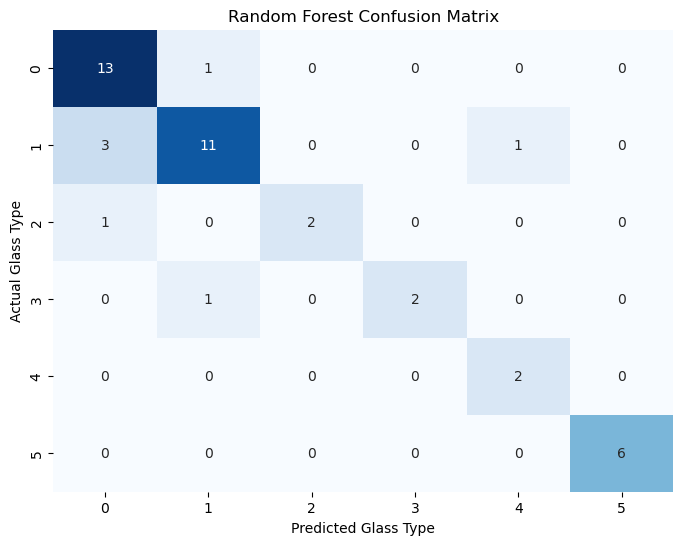

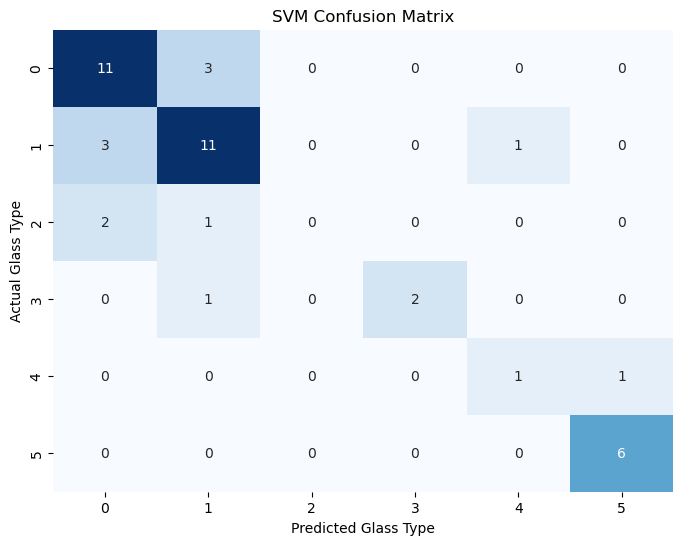

In [7]:
def plot_confusion_matrix(cm, title, filename):
    """
    This function creates a heatmap for the confusion matrix.
    """
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(title)
    plt.xlabel('Predicted Glass Type')
    plt.ylabel('Actual Glass Type')
    plt.show() # In a Jupyter Notebook, plt.show() will display the plot

# Plot for Random Forest
plot_confusion_matrix(cm_rf, "Random Forest Confusion Matrix", "rf_confusion_matrix.png")

# Plot for SVM
plot_confusion_matrix(cm_svm, "SVM Confusion Matrix", "svm_confusion_matrix.png")